### Libraries, data and Functions

In [2]:
import sys
import os

# Agrega el directorio anterior al sys.path
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import my_module as mm
from scipy import stats
import importlib
import scipy.linalg as la
from getdist import MCSamples, plots
from scipy.constants import c

#Refresh the changes made on my_module files
importlib.reload(mm)


#Matplotlib parameters

plt.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # Or your preferred from the list
    "font.size": 14,                 # Base font size for all text

    # Axes labels & title sizes
    "axes.titlesize": 16,
    "axes.labelsize": 14,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

})

from matplotlib.lines import Line2D

# Define custom legend entries (no markers, no lines, just colored text)
labels = ["Pantheon+", "DES 5yr"]
colors = ["chocolate", 'darkgreen']

# Create fake handles for legend
custom_handles = [
    Line2D([0], [0], color='none', marker='None', label=label)
    for label in labels
]

In [12]:
#Pantheon+ data import
data_Pan, cov_Pan = mm.data_import.Pantheon_data(cut=False)

#DES data import
data_DES, cov_DES = mm.data_import.DES_data(cut=False)

#Sort data by redshift
data_DES = data_DES.sort_values(by='zHD')
data_Pan = data_Pan.sort_values(by='zHD')

In [17]:
text_folder = '../../text/images/'

In [14]:
#Define parameter names and labels
param_names = ['om_m', 'H0']  
labels = [r'\Omega_m', r'H_0']

#data import from MCMC chains
data_Pantheon = np.loadtxt("samples_Pan.txt")
data_DES5yr = np.loadtxt("samples_DES.txt")
data_PanCeph = np.loadtxt("samples_PanCeph.txt")


#Convert it into MCSamples object
samples_Pantheon = MCSamples(samples=data_Pantheon, names=param_names, labels=labels)
samples_DES5yr = MCSamples(samples=data_DES5yr, names=param_names, labels=labels)
samples_PanCeph = MCSamples(samples=data_PanCeph, names=param_names, labels=labels)

# Function to summarize MCSamples
def summarize_mc_samples(mc_sample, sample_name):
    """
    Print mean ± standard deviation for each parameter in an MCSamples object.
    
    Parameters
    ----------
    mc_sample : MCSamples
        MCSamples object containing the MCMC samples.
    """
    param_names = mc_sample.getParamNames().names
    for name in param_names:
        mean = mc_sample.mean(name)
        err = mc_sample.std(name)
        print(f"{sample_name} - {name}: {mean:.4f} ± {err:.4f}")

Removed no burn in
Removed no burn in
Removed no burn in


### Overview

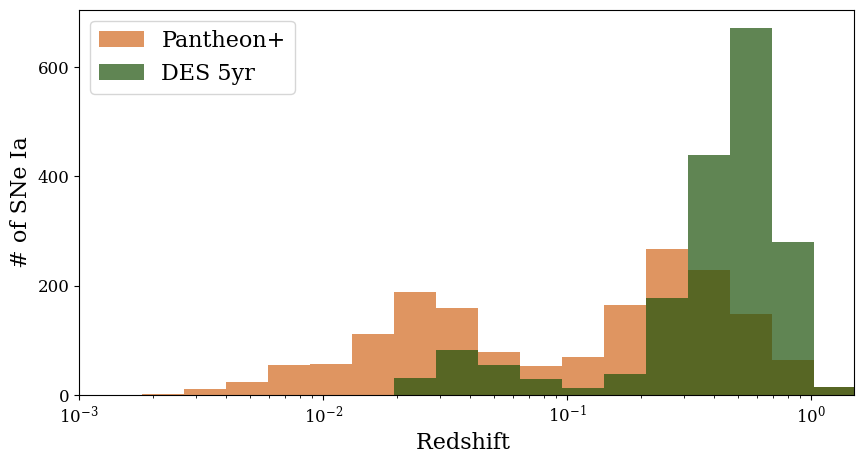

In [18]:
log_bins_Pan = np.logspace(np.log10(data_Pan['zHD'].min()), np.log10(data_Pan['zHD'].max()), 20)

gr = (29/255,82/255,10/255)

plt.figure(figsize=(10, 5))
plt.hist(data_Pan['zHD'], bins=log_bins_Pan, color='chocolate', alpha=0.70, label='Pantheon+')
plt.hist(data_DES['zHD'], bins=log_bins_Pan, color=gr, alpha=0.70, label='DES 5yr')
plt.xscale('log')
plt.xlabel('Redshift ', fontsize=16)
plt.ylabel('# of SNe Ia', fontsize=16)
plt.yticks(np.arange(0, 701, 200))
plt.xlim(0.001, 1.5)
plt.legend(fontsize=16)
plt.savefig(text_folder + 'hist_redshift.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_19911/1754028714.py:19: RuntimeWarning: divide by zero encountered in log10
  mu_sh0es = 5* np.log10(distance_shoes) + 25
/tmp/ipykernel_19911/1754028714.py:22: RuntimeWarning: divide by zero encountered in log10
  mu_planck = 5* np.log10(distance_planck) + 25
/tmp/ipykernel_19911/1754028714.py:31: RuntimeWarning: invalid value encountered in subtract
  ax2.plot(z_uniform, mu_planck - mu_sh0es, color='firebrick', label=r'Planck (best-fit $\Lambda CDM$)', linewidth=1.5)


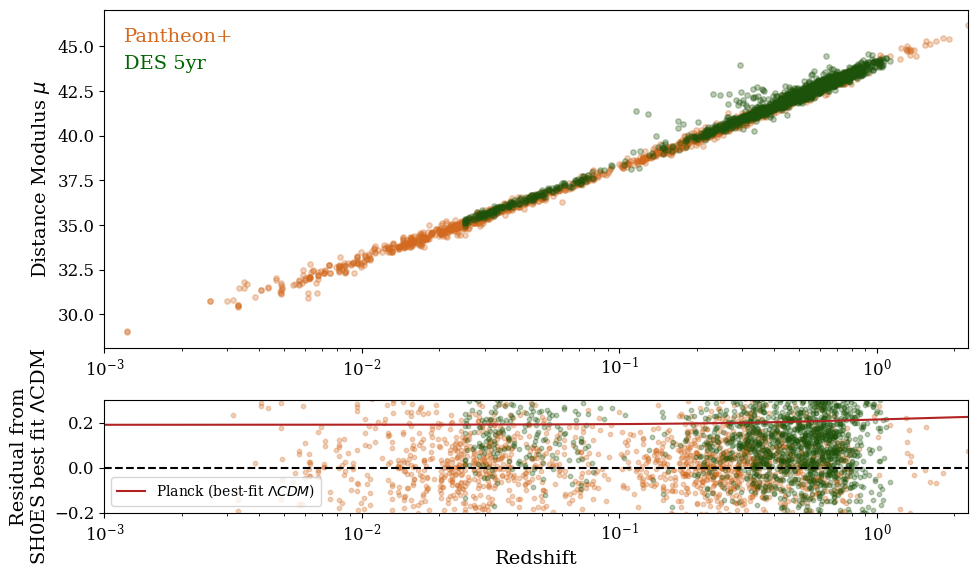

In [19]:
 # Crear la figura y los subplots: uno arriba (grafico principal) y otro abajo (residuos)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

# Gráfico principal: datos reales vs. modelo
ax1.scatter(data_Pan['zHD'], data_Pan['MU_SH0ES'], s=15, color='chocolate', alpha=0.3)
ax1.scatter(data_DES['zHD'], data_DES['MU_SH0ES'], s=15, color=gr, alpha=0.3)
ax1.set_ylabel(r'Distance Modulus $\mu$')
ax1.set_xscale('log')
ax1.set_xlim(0.001, 2.26)
leg = ax1.legend(handles=custom_handles, handlelength=0, handletextpad=0.1, frameon=False)


for text, color in zip(leg.get_texts(), colors):
    text.set_color(color)

z_uniform = np.linspace(0, 2.26, 10000)

distance_shoes = mm.FlatModel.dist(z_uniform) #SH0ES values for H0 y om_m
mu_sh0es = 5* np.log10(distance_shoes) + 25

distance_planck = mm.FlatModel.dist(z_uniform, h0=67.4, om_m=0.315) #Planck values for H0 y om_m
mu_planck = 5* np.log10(distance_planck) + 25

residuals_DES = data_DES['MU_SH0ES'] - (5* np.log10(mm.FlatModel.dist(data_DES['zHD'])) + 25)
residuals_Pan = data_Pan['MU_SH0ES'] - (5* np.log10(mm.FlatModel.dist(data_Pan['zHD'])) + 25)

# Gráfico inferior: residuos (diferencia entre datos reales y modelo)
ax2.scatter(data_Pan['zHD'], residuals_Pan, color='chocolate', s=10, alpha=0.3)
ax2.scatter(data_DES['zHD'], residuals_DES, color=gr, s=10, alpha=0.3)
ax2.axhline(0, color='black', linestyle='--')  # Línea en y=0 para referencia
ax2.plot(z_uniform, mu_planck - mu_sh0es, color='firebrick', label=r'Planck (best-fit $\Lambda CDM$)', linewidth=1.5)
ax2.set_xscale('log')
ax2.set_xlim(0.001, 2.26)
ax2.set_ylim(-0.2, 0.3)
ax2.set_xlabel('Redshift')
ax2.set_ylabel(r'Residual from' '\n' r'SH0ES best fit $\Lambda$CDM')
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig(text_folder + 'mu_z.png', dpi=300, bbox_inches='tight')
plt.show()

### MCMC

Pantheon - om_m	\Omega_m: 0.3668 ± 0.0416
Pantheon - H0	H_0: 72.6310 ± 0.5617


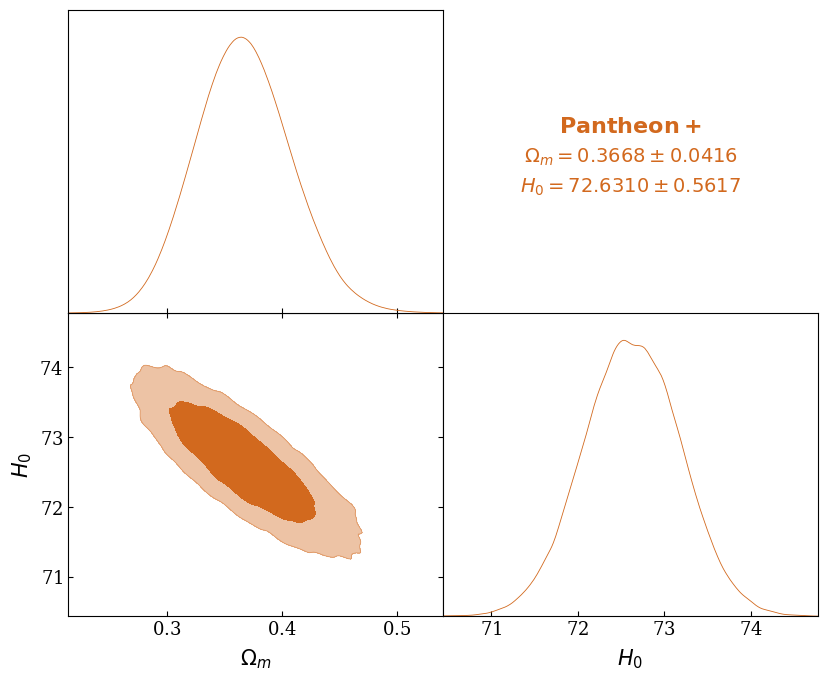

In [20]:
mm.make_triangle_plot(
    samples_Pantheon,
    labels=labels,
    colors=['chocolate'],
    outfile=text_folder + 'full_Pantheon.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+']
)

summarize_mc_samples(samples_Pantheon, sample_name='Pantheon')

Pantheon+ & Cepheids - om_m	\Omega_m: 0.3681 ± 0.0416
Pantheon+ & Cepheids - H0	H_0: 72.6275 ± 0.5616
CF3 param on Pantheon+ - om_m	\Omega_m: 0.3668 ± 0.0416
CF3 param on Pantheon+ - H0	H_0: 72.6310 ± 0.5617


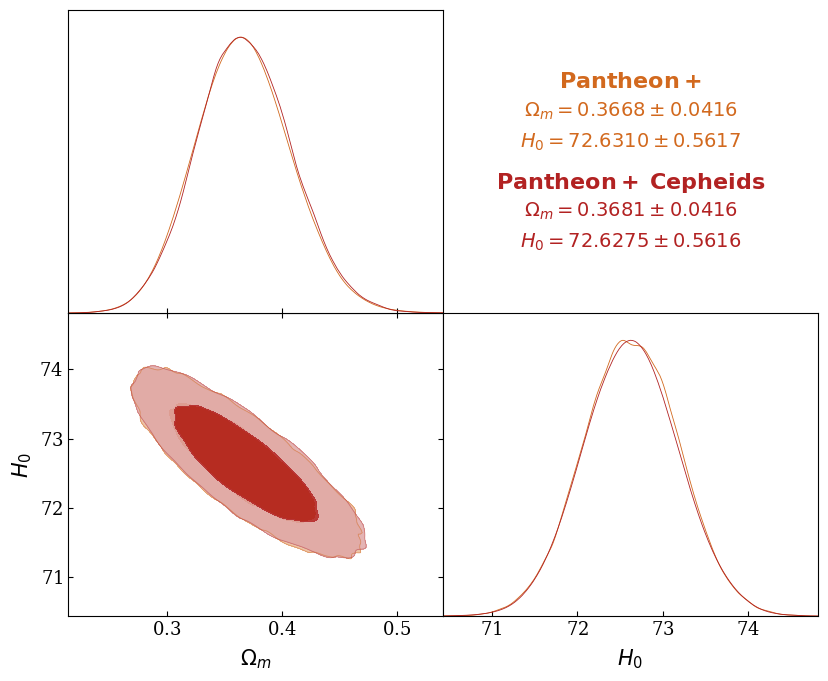

In [21]:
mm.make_triangle_plot(
    [samples_Pantheon, samples_PanCeph],
    labels=labels,
    colors=('chocolate', 'firebrick'),
    outfile=text_folder + 'full_PanCeph.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', r'Pantheon+ \; Cepheids']
)

summarize_mc_samples(samples_PanCeph, sample_name='Pantheon+ & Cepheids')
summarize_mc_samples(samples_Pantheon, sample_name='CF3 param on Pantheon+')

DES 5yr - om_m	\Omega_m: 0.2762 ± 0.0222
DES 5yr - H0	H_0: 69.5402 ± 0.5423


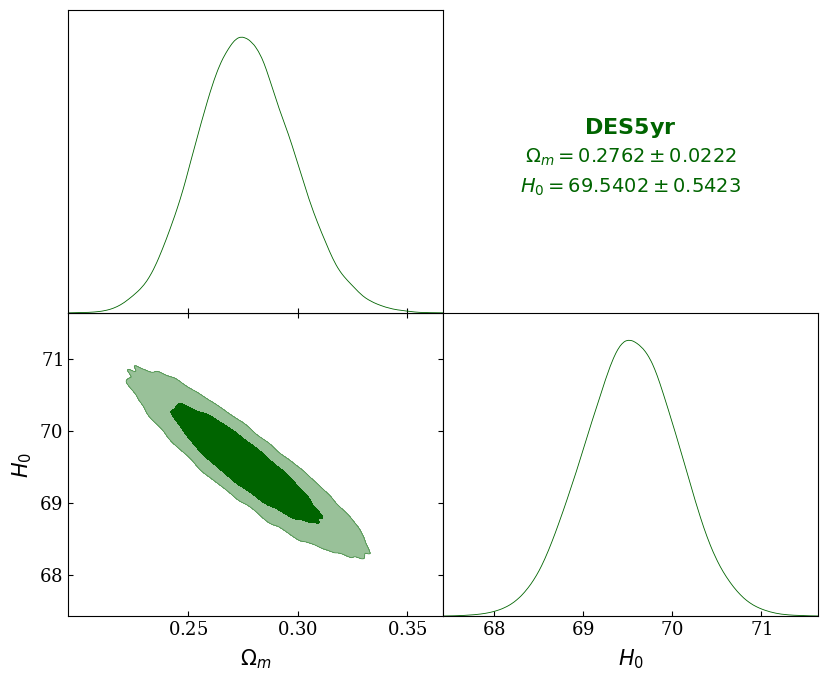

In [22]:
mm.make_triangle_plot(
    samples_DES5yr,
    labels=labels,
    colors=['darkgreen'],
    outfile=text_folder + 'full_DES.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['DES 5yr']
)

summarize_mc_samples(samples_DES5yr, sample_name='DES 5yr')